In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("student_scores.csv")
df.head(5)
df.tail(5)

,Hours,Scores
13,8.0,80
14,8.5,85
15,9.0,90
16,9.5,95
17,10.0,100


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   18 non-null     float64
 1   Scores  18 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 420.0 bytes


In [10]:
df.isnull().sum()

Hours     0
Scores    0
dtype: int64

In [11]:
df.columns

Index(['Hours', 'Scores'], dtype='str')

In [15]:
df.dtypes

Hours     float64
Scores      int64
dtype: object

## splitting feature (input value) and target (predicted output)

In [34]:
# X = df["Hours"] # feature 1-D
X = df[["Hours"]] # feature as 2-D
y = df["Scores"] # target

In [35]:
print(X.ndim)
print(y.ndim)

2
1


In [36]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: /home/alex-spencer/anaconda3/envs/data_science/lib/python3.13/site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: 


In [37]:
from sklearn.model_selection import train_test_split

## Training (80%) and Testing (20%)

In [39]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [45]:
from sklearn.linear_model import LinearRegression

In [46]:
model = LinearRegression()

### Training model

In [47]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
features = pd.DataFrame([[6.83]], columns=X.columns)
predicted_value = model.predict(features)
print(predicted_value)

[68.44499907]


In [54]:
import matplotlib.pyplot as plt

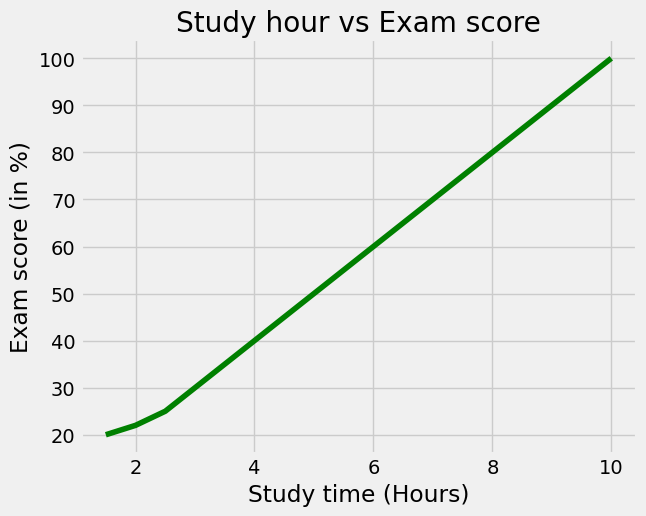

m: [9.7096955]
b: 2.1277788156174253
r: 0.9982807887025449


In [71]:
xData = X
yData = y

plt.style.use("fivethirtyeight")

plt.plot(xData,yData,color='g')
plt.tight_layout()

plt.title("Study hour vs Exam score")
plt.xlabel("Study time (Hours)")
plt.ylabel("Exam score (in %)")

plt.show()

print(f"m: {model.coef_}")
print(f"b: {model.intercept_}")
print(f"r: {model.score(xData,yData)}")
